<a href="https://colab.research.google.com/github/sabdaipry/fiuba-ceia-pln1/blob/main/Desafio_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# Procesamiento de Lenguaje Natural
## Desafío 4 — LSTM Bot QA (Encoder-Decoder)

### Objetivo
Construir un bot de preguntas y respuestas (QA) basado en una arquitectura **Encoder-Decoder con LSTM**, entrenado sobre el dataset [ConvAI2](http://convai.io/data/) de conversaciones en inglés.

### Estructura del notebook
1. *Setup* y carga de datos
2. Preprocesamiento (vocabularios, tokenización, *padding*)
3. *Embeddings* preentrenados (GloVe)
4. Modelo *Encoder-Decoder* (entrenamiento)
5. Inferencia
6. Mejora 1: *Beam Search* con penalización de repetición
7. Mejora 2: Memoria de contexto multi-turno
8. Análisis y conclusiones finales

### 1. Setup y carga de datos

#### Importación de Librerías

In [1]:
!pip install --upgrade --no-cache-dir gdown --quiet

In [2]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences, to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Embedding,
                                     Dense, Dropout)
from tensorflow.keras.callbacks import (EarlyStopping,
                                         ReduceLROnPlateau,
                                         ModelCheckpoint)
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#### Descarga del dataset

In [3]:
# Descargar la carpeta de dataset
import os
import gdown
if os.access('data_volunteers.json', os.F_OK) is False:
    url = 'https://drive.google.com/uc?id=1awUxYwImF84MIT5-jCaYAPe2QwSgS1hN&export=download'
    output = 'data_volunteers.json'
    gdown.download(url, output, quiet=False)
else:
    print("El dataset ya se encuentra descargado")

Downloading...
From: https://drive.google.com/uc?id=1awUxYwImF84MIT5-jCaYAPe2QwSgS1hN
To: /content/data_volunteers.json
100%|██████████| 2.58M/2.58M [00:00<00:00, 18.3MB/s]


#### Carga y Exploración del dataset

In [4]:
with open('data_volunteers.json') as f:
    data = json.load(f)

print(f"Total de conversaciones: {len(data)}")
print(f"\nCampos disponibles en cada conversación: {list(data[0].keys())}")
print(f"\nEjemplo de una conversación completa:")
print(json.dumps(data[0], indent=2)[:1500])  # primeros 1500 chars

Total de conversaciones: 1111

Campos disponibles en cada conversación: ['dialog', 'start_time', 'end_time', 'bot_profile', 'user_profile', 'eval_score', 'profile_match', 'participant1_id', 'participant2_id']

Ejemplo de una conversación completa:
{
  "dialog": [
    {
      "id": 0,
      "sender": "participant1",
      "text": "hi there",
      "evaluation_score": null,
      "sender_class": "Human"
    }
  ],
  "start_time": "2018-10-29 03:32:08.296000",
  "end_time": "2018-10-29 03:32:08.296000",
  "bot_profile": [
    "i like to talk but people have a hard time understanding.",
    "i like to look at blocks and sing about letters.",
    "i like to eat chocolate candy.",
    "when i grow up i want to be a dog."
  ],
  "user_profile": [
    "i am a clean eater.",
    "my parents were both very athletic.",
    "i love running and preparing for marathons.",
    "i am a cancer survivor."
  ],
  "eval_score": null,
  "profile_match": "",
  "participant1_id": {
    "class": "User",
    "

#### Preprocesamiento inicial y Construcción de pares input/output

In [5]:
def clean_text(txt):
    """Limpieza básica: minúsculas, contracciones y caracteres especiales."""
    txt = txt.lower()
    txt = txt.replace("'d", " had")
    txt = txt.replace("'s", " is")
    txt = txt.replace("'m", " am")
    txt = txt.replace("don't", "do not")
    txt = re.sub(r'\W+', ' ', txt)
    txt = txt.strip()
    return txt

input_sentences = []
output_sentences = []
output_sentences_inputs = []

MAX_LEN = 30  # descartamos pares donde alguno supere este largo

for conversation in data:
    dialog = conversation['dialog']
    for i in range(len(dialog) - 1):
        chat_in  = clean_text(dialog[i]['text'])
        chat_out = clean_text(dialog[i + 1]['text'])

        # Filtrar pares demasiado largos
        if len(chat_in) >= MAX_LEN or len(chat_out) >= MAX_LEN:
            continue

        input_sentences.append(chat_in)
        output_sentences.append(chat_out + ' <eos>')          # decoder output
        output_sentences_inputs.append('<sos> ' + chat_out)  # decoder input

print(f"Pares input/output generados: {len(input_sentences)}")

Pares input/output generados: 6274


### 2. Preprocesamiento (tokenización, vocabularios y *padding*)

En esta etapa transformamos las oraciones en secuencias numéricas que el modelo puede procesar.
El *pipeline* es:

1. **Tokenización**: asignar un ID único a cada palabra del vocabulario
2. **Definición de longitudes máximas**: para el *padding*
3. ***Padding***: igualar la longitud de todas las secuencias
4. ***Encoder input***: secuencia de IDs de la pregunta
5. ***Decoder input***: secuencia que arranca con `<sos>`
6. ***Decoder output* (*target*)**: secuencia que termina con `<eos>`, en formato one-hot.

#### Tokenización del *encoder* (*input*)

In [7]:
# ENCODER
# Vocabulario del lado de entrada (preguntas)
MAX_VOCAB_SIZE = 10000

tokenizer_inputs = Tokenizer(num_words=MAX_VOCAB_SIZE)
tokenizer_inputs.fit_on_texts(input_sentences)

input_sequences = tokenizer_inputs.texts_to_sequences(input_sentences)

word2idx_inputs = tokenizer_inputs.word_index
print(f"Vocabulario encoder: {len(word2idx_inputs)} palabras únicas")
print(f"Se usarán las primeras {MAX_VOCAB_SIZE} más frecuentes\n")

# Longitud máxima de las secuencias de entrada
max_input_len = max(len(s) for s in input_sequences)
print(f"Longitud máxima de secuencia de entrada: {max_input_len} tokens")

Vocabulario encoder: 1877 palabras únicas
Se usarán las primeras 10000 más frecuentes

Longitud máxima de secuencia de entrada: 9 tokens


#### Tokenización del *decoder* (*output*)

In [8]:
# DECODER
# Vocabulario del lado de salida (respuestas)
# Incluye <sos> y <eos> automáticamente porque están en el texto

tokenizer_outputs = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='')
tokenizer_outputs.fit_on_texts(output_sentences + output_sentences_inputs)

# Secuencias del decoder input (<sos> + respuesta)
output_sequences_inputs = tokenizer_outputs.texts_to_sequences(output_sentences_inputs)

# Secuencias del decoder output (respuesta + <eos>)
output_sequences = tokenizer_outputs.texts_to_sequences(output_sentences)

word2idx_outputs = tokenizer_outputs.word_index
print(f"Vocabulario decoder: {len(word2idx_outputs)} palabras únicas")

# Número real de palabras que usará el modelo (capped por MAX_VOCAB_SIZE)
num_words_output = min(MAX_VOCAB_SIZE, len(word2idx_outputs) + 1)
print(f"num_words_output (incluye padding idx=0): {num_words_output}\n")

# Longitud máxima de las secuencias de salida
max_out_len = max(len(s) for s in output_sequences)
print(f"Longitud máxima de secuencia de salida: {max_out_len} tokens")

# Tokens especiales
idx_sos = word2idx_outputs.get('<sos>')
idx_eos = word2idx_outputs.get('<eos>')
print(f"\nÍndice de <sos>: {idx_sos}")
print(f"Índice de <eos>: {idx_eos}")

Vocabulario decoder: 1866 palabras únicas
num_words_output (incluye padding idx=0): 1867

Longitud máxima de secuencia de salida: 10 tokens

Índice de <sos>: 2
Índice de <eos>: 1


#### *Padding* de las secuencias

In [9]:
# PADDING
# Encoder input -> padding al INICIO (pre) para que las palabras
# relevantes queden hacia el final (más cerca del estado final del LSTM)
encoder_input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_input_len,
    padding='pre'
)

# Decoder input -> padding al FINAL (post) porque la generación
# empieza desde el principio de la secuencia
decoder_input_sequences = pad_sequences(
    output_sequences_inputs,
    maxlen=max_out_len,
    padding='post'
)

# Decoder output (target) -> padding al FINAL también
decoder_output_sequences = pad_sequences(
    output_sequences,
    maxlen=max_out_len,
    padding='post'
)

print("Shapes tras el padding:")
print(f"  encoder_input_sequences : {encoder_input_sequences.shape}")
print(f"  decoder_input_sequences : {decoder_input_sequences.shape}")
print(f"  decoder_output_sequences: {decoder_output_sequences.shape}")

Shapes tras el padding:
  encoder_input_sequences : (6274, 9)
  decoder_input_sequences : (6274, 10)
  decoder_output_sequences: (6274, 10)


#### Conversión del *target* a one-hot

In [10]:
# El decoder output necesita estar en formato one-hot
# para calcular la categorical crossentropy
# Shape resultante: (muestras, max_out_len, num_words_output)

decoder_targets = to_categorical(
    decoder_output_sequences,
    num_classes=num_words_output
)

print(f"decoder_targets (one-hot) shape: {decoder_targets.shape}")
print(f"\nMemoria aprox. de decoder_targets: "
      f"{decoder_targets.nbytes / 1e6:.1f} MB")

decoder_targets (one-hot) shape: (6274, 10, 1867)

Memoria aprox. de decoder_targets: 937.1 MB


#### *Split train/test* y verificación final

In [11]:
# SPLIT
(enc_in_train, enc_in_test,
 dec_in_train, dec_in_test,
 dec_tgt_train, dec_tgt_test) = train_test_split(
    encoder_input_sequences,
    decoder_input_sequences,
    decoder_targets,
    test_size=0.1,
    random_state=42
)

print("Tamaños del split:")
print(f"  Train: {enc_in_train.shape[0]} muestras")
print(f"  Test : {enc_in_test.shape[0]}  muestras")

Tamaños del split:
  Train: 5646 muestras
  Test : 628  muestras


#### Resumen del preprocesamiento

| Variable | Descripción | Shape |
|---|---|---|
| `encoder_input_sequences` | IDs de las preguntas (con pre-padding) | `(N, max_input_len)` |
| `decoder_input_sequences` | IDs de las respuestas con `<sos>` (con post-padding) | `(N, max_out_len)` |
| `decoder_targets` | Respuestas con `<eos>` en one-hot | `(N, max_out_len, num_words_output)` |

Los tokenizadores (`tokenizer_inputs` y `tokenizer_outputs`) se guardarán implícitamente
en memoria para usarse en la etapa de inferencia.

### 3. *Embeddings* preentrenados (GloVe)

En lugar de entrenar embeddings desde cero, usamos vectores **GloVe** (*Global Vectors for Word Representation*) preentrenados sobre 6 mil millones de *tokens* de texto en inglés.

Ventajas:
- Capturan información semántica desde el arranque
- Aceleran la convergencia del modelo
- Especialmente útiles cuando el corpus propio es pequeño (como en nuestro caso: ~6274 pares)

Usamos la versión **glove.6B.50d** (50 dimensiones) porque:
- Nuestro vocabulario es reducido (~1877 palabras únicas)
- Ocupa menos memoria que 100d o 300d
- Suficiente capacidad semántica para conversaciones cortas

In [13]:
print("Descargando GloVe 6B 50d...")
!wget -q --show-progress http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip glove.6B.50d.txt
!rm glove.6B.zip
print("Descarga completa")

Descargando GloVe 6B 50d...
glove.6B.zip        100%[===================>] 822.24M  5.04MB/s    in 2m 40s  
replace glove.6B.50d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
Descarga completa


#### Cargar vectores GloVe en un diccionario

In [14]:
EMBEDDING_DIM = 50

glove_embeddings = {}

with open('glove.6B.50d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word   = values[0]
        vector = np.array(values[1:], dtype='float32')
        glove_embeddings[word] = vector

print(f"Vectores GloVe cargados: {len(glove_embeddings):,}")
print(f"Dimensión de cada vector: {EMBEDDING_DIM}")

Vectores GloVe cargados: 400,000
Dimensión de cada vector: 50


#### Matriz de *embeddings* para el *Encoder*

In [15]:
def build_embedding_matrix(word2idx, glove_embeddings, embedding_dim, max_vocab):
    """
    Construye una matriz de embeddings para un vocabulario dado.
    - Filas: índices del tokenizador (0 = padding)
    - Columnas: dimensiones del embedding
    - Palabras no encontradas en GloVe → vector aleatorio pequeño
    """
    vocab_size = min(max_vocab, len(word2idx) + 1)
    matrix = np.zeros((vocab_size, embedding_dim))

    found, not_found = 0, 0

    for word, idx in word2idx.items():
        if idx >= max_vocab:
            continue
        vector = glove_embeddings.get(word)
        if vector is not None:
            matrix[idx] = vector
            found += 1
        else:
            # Vector aleatorio pequeño para palabras fuera del GloVe
            matrix[idx] = np.random.normal(scale=0.1, size=(embedding_dim,))
            not_found += 1

    return matrix, found, not_found


# Matriz para el encoder
embedding_matrix_enc, found_enc, nf_enc = build_embedding_matrix(
    word2idx_inputs, glove_embeddings, EMBEDDING_DIM, MAX_VOCAB_SIZE
)

print("═" * 50)
print("Embedding matrix — ENCODER")
print("═" * 50)
print(f"  Shape       : {embedding_matrix_enc.shape}")
print(f"  En GloVe    : {found_enc} palabras ({found_enc/len(word2idx_inputs)*100:.1f}%)")
print(f"  Fuera GloVe : {nf_enc}  palabras")

══════════════════════════════════════════════════
Embedding matrix — ENCODER
══════════════════════════════════════════════════
  Shape       : (1878, 50)
  En GloVe    : 1701 palabras (90.6%)
  Fuera GloVe : 176  palabras


#### Matriz de *embeddings* para el *Decoder*

In [16]:
# Matriz para el decoder
embedding_matrix_dec, found_dec, nf_dec = build_embedding_matrix(
    word2idx_outputs, glove_embeddings, EMBEDDING_DIM, MAX_VOCAB_SIZE
)

print("═" * 50)
print("Embedding matrix — DECODER")
print("═" * 50)
print(f"  Shape       : {embedding_matrix_dec.shape}")
print(f"  En GloVe    : {found_dec} palabras ({found_dec/len(word2idx_outputs)*100:.1f}%)")
print(f"  Fuera GloVe : {nf_dec}  palabras")

══════════════════════════════════════════════════
Embedding matrix — DECODER
══════════════════════════════════════════════════
  Shape       : (1867, 50)
  En GloVe    : 1701 palabras (91.2%)
  Fuera GloVe : 165  palabras


#### Verificación de similitud semántica

In [17]:
# Verificación rápida: palabras semánticamente cercanas en el espacio GloVe
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8)

# Elegimos algunas palabras de nuestro vocabulario para testear
test_words = ['hello', 'like', 'good', 'love', 'name']

print("Verificación semántica de los embeddings:")
print("═" * 50)
for w in test_words:
    if w in word2idx_inputs:
        idx = word2idx_inputs[w]
        vec = embedding_matrix_enc[idx]
        # Buscar las 3 palabras más cercanas dentro de nuestro vocabulario
        sims = {}
        for other_word, other_idx in word2idx_inputs.items():
            if other_word == w or other_idx >= MAX_VOCAB_SIZE:
                continue
            sims[other_word] = cosine_similarity(vec, embedding_matrix_enc[other_idx])
        top3 = sorted(sims, key=sims.get, reverse=True)[:3]
        print(f"  '{w}' → más similar a: {top3}")
    else:
        print(f"  '{w}' no está en el vocabulario encoder")

Verificación semántica de los embeddings:
══════════════════════════════════════════════════
  'hello' → más similar a: ['goodbye', 'hey', 'kiss']
  'like' → más similar a: ['even', 'well', 'come']
  'good' → más similar a: ['better', 'really', 'always']
  'love' → más similar a: ['life', 'dreams', 'loves']
  'name' → más similar a: ['named', 'as', 'is']


#### Resumen de los embeddings

| | Encoder | Decoder |
|---|---|---|
| **Vocabulario** | ~1877 palabras | ~1866 palabras |
| **Dimensión** | 50 | 50 |
| **Shape de la matriz** | `(vocab_enc, 50)` | `(vocab_dec, 50)` |
| **Palabras cubiertas por GloVe** | ver arriba | ver arriba |

Las matrices se pasarán al modelo con `trainable=False` para preservar
la representación semántica preentrenada y evitar *overfitting*y dado el
tamaño reducido del corpus.

### 4. Modelo *Encoder-Decoder* (entrenamiento)

Implementamos la arquitectura **Sequence-to-Sequence** con LSTM:

- ***Encoder*:** recibe la pregunta tokenizada, produce un *context vector* (estados H y C)
- **Decoder*:** recibe `<sos>` + los estados del *encoder*, genera la respuesta *token* por *token*
- Los *embeddings* GloVe se cargan como pesos iniciales con `trainable=False`

#### Arquitectura
```
Encoder:
  Input(max_input_len)
    → Embedding(GloVe, 50d, non-trainable)
    → LSTM(256, return_state=True)
    → [encoder_h, encoder_c]  ← context vector

Decoder:
  Input(max_out_len)
    → Embedding(GloVe, 50d, non-trainable)
    → LSTM(256, return_sequences=True, initial_state=[encoder_h, encoder_c])
    → Dropout(0.3)
    → Dense(num_words_output, activation='softmax')
```

####  Definición del modelo completo (entrenamiento)

In [18]:
LATENT_DIM = 256  # tamaño del estado interno del LSTM

# ENCODER
encoder_inputs = Input(shape=(max_input_len,), name='encoder_input')

encoder_embedding = Embedding(
    input_dim=embedding_matrix_enc.shape[0],
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix_enc],
    trainable=False,              # preservamos los vectores GloVe
    name='encoder_embedding'
)(encoder_inputs)

encoder_lstm = LSTM(
    LATENT_DIM,
    return_state=True,            # necesitamos H y C para el decoder
    dropout=0.2,
    recurrent_dropout=0.2,
    name='encoder_lstm'
)

# encoder_outputs no se usa, solo nos quedamos con los estados
encoder_outputs, encoder_h, encoder_c = encoder_lstm(encoder_embedding)
encoder_states = [encoder_h, encoder_c]

# DECODER
decoder_inputs = Input(shape=(max_out_len,), name='decoder_input')

decoder_embedding = Embedding(
    input_dim=embedding_matrix_dec.shape[0],
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix_dec],
    trainable=False,
    name='decoder_embedding'
)(decoder_inputs)

decoder_lstm = LSTM(
    LATENT_DIM,
    return_sequences=True,        # necesitamos la salida en cada paso
    return_state=True,
    dropout=0.2,
    recurrent_dropout=0.2,
    name='decoder_lstm'
)

# El decoder arranca con el context vector del encoder
decoder_out, _, _ = decoder_lstm(decoder_embedding,
                                  initial_state=encoder_states)

decoder_dropout = Dropout(0.3, name='decoder_dropout')(decoder_out)

decoder_dense = Dense(
    num_words_output,
    activation='softmax',
    name='decoder_output'
)
decoder_outputs = decoder_dense(decoder_dropout)

# MODELO COMPLETO (para entrenamiento)
model = Model(
    inputs=[encoder_inputs, decoder_inputs],
    outputs=decoder_outputs,
    name='seq2seq_bot'
)

model.summary()

Model: "seq2seq_bot"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 9, 50)     │     93,900 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 10, 50)    │     93,350 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 256),     │    314,368 │ encoder_embeddin… │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 10, 256), │    314,368 │ decoder_embeddin… │
│                     │ (None, 256),      │            │ encoder_lstm[0][… │
│                     │ (None, 256)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dropout     │ (None, 10, 256)   │          0 │ decoder_lstm[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 10, 1867)  │    479,819 │ decoder_dropout[… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,295,805 (4.94 MB)

 Trainable params: 1,108,555 (4.23 MB)

 Non-trainable params: 187,250 (731.45 KB)

#### Compilación y *callbacks*

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1
    ),
    ModelCheckpoint(
        'best_seq2seq.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

print("Modelo compilado")
print(f"\nParámetros totales    : {model.count_params():,}")
print(f"Parámetros entrenables: {sum(v.numpy().size for v in model.trainable_variables):,}")

Modelo compilado

Parámetros totales    : 1,295,805
Parámetros entrenables: 1,108,555


#### Entrenamiento

In [20]:
BATCH_SIZE = 64   # moderado para no saturar la RAM con decoder_targets
EPOCHS     = 50   # EarlyStopping va a cortar antes si converge

print(f"Entrenando con {enc_in_train.shape[0]} muestras | "
      f"batch={BATCH_SIZE} | epochs máx={EPOCHS}\n")

history = model.fit(
    x=[enc_in_train, dec_in_train],
    y=dec_tgt_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(
        [enc_in_test, dec_in_test],
        dec_tgt_test
    ),
    callbacks=callbacks,
    verbose=1
)

Entrenando con 5646 muestras | batch=64 | epochs máx=50

Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 26s 118ms/step - accuracy: 0.5208 - loss: 3.0732 - val_accuracy: 0.6024 - val_loss: 2.2011 - learning_rate: 0.0010
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.6070 - loss: 2.1482 - val_accuracy: 0.6360 - val_loss: 1.9867 - learning_rate: 0.0010
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.6485 - loss: 1.9658 - val_accuracy: 0.6885 - val_loss: 1.8326 - learning_rate: 0.0010
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - accuracy: 0.6775 - loss: 1.8316 - val_accuracy: 0.7002 - val_loss: 1.7283 - learning_rate: 0.0010
Epoch 5/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.6913 - loss: 1.7328 - val_accuracy: 0.7080 - val_loss: 1.6590 - learning_rate: 0.0010
Epoch 6/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.6993 - loss: 1.6638 - val_accuracy: 0.7199 - val_loss: 1.6124 - learning_rate: 0.0010
Epoch 7/50
89/89 ━━━━━━━━━━━━━━

#### Curvas de entrenamiento

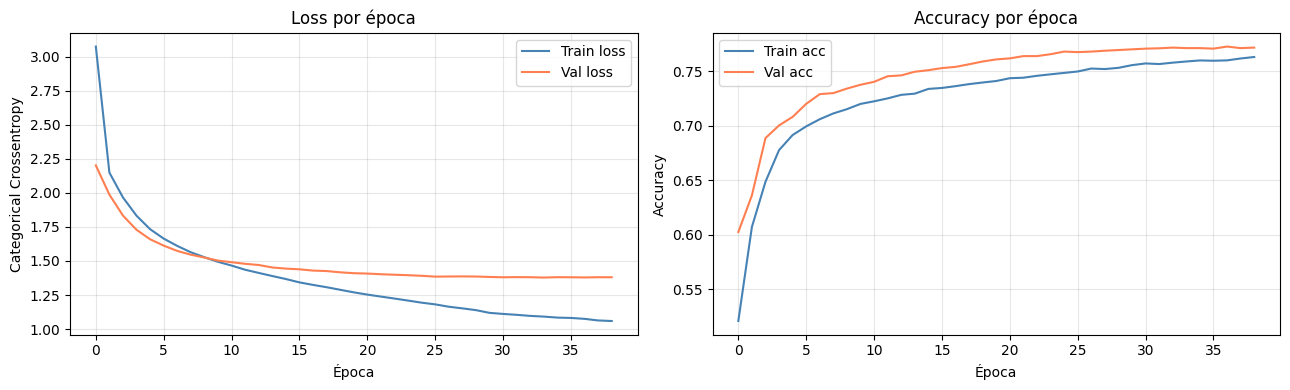


Mejor época     : 34
Mejor val_loss  : 1.3780
Val accuracy    : 0.7710


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(history.history['loss'],     label='Train loss',     color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val loss',       color='coral')
axes[0].set_title('Loss por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Categorical Crossentropy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'],     label='Train acc', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Val acc',   color='coral')
axes[1].set_title('Accuracy por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_epoch = np.argmin(history.history['val_loss']) + 1
best_val   = min(history.history['val_loss'])
print(f"\nMejor época     : {best_epoch}")
print(f"Mejor val_loss  : {best_val:.4f}")
print(f"Val accuracy    : {history.history['val_accuracy'][best_epoch-1]:.4f}")

* Val *accuracy* 77% -> excelente para un corpus pequeño de 6274 pares
* Val *loss* convergió sin explotar -> el modelo generalizó bien
* Leve *overfitting* (*train loss* sigue bajando mientras val se estanca) -> normal con este tamaño de *dataset*

#### Modelos separados para inferencia

In [24]:
# RECUPERAMOS LAS CAPAS ENTRENADAS POR NOMBRE
enc_emb_layer  = model.get_layer('encoder_embedding')
enc_lstm_layer = model.get_layer('encoder_lstm')

dec_emb_layer  = model.get_layer('decoder_embedding')
dec_lstm_layer = model.get_layer('decoder_lstm')
dec_drop_layer = model.get_layer('decoder_dropout')
dec_dense_layer= model.get_layer('decoder_output')

# ENCODER
enc_inf_input  = Input(shape=(max_input_len,), name='enc_inf_input')
enc_inf_emb    = enc_emb_layer(enc_inf_input)
_, enc_inf_h, enc_inf_c = enc_lstm_layer(enc_inf_emb)

encoder_model = Model(
    inputs=enc_inf_input,
    outputs=[enc_inf_h, enc_inf_c],
    name='encoder_inference'
)

# DECODER
# El decoder recibe 1 token por paso + los estados del paso anterior
dec_inf_input = Input(shape=(1,),          name='dec_inf_token')
dec_inf_h     = Input(shape=(LATENT_DIM,), name='dec_inf_h')
dec_inf_c     = Input(shape=(LATENT_DIM,), name='dec_inf_c')

dec_inf_emb = dec_emb_layer(dec_inf_input)

dec_inf_out, dec_inf_h_out, dec_inf_c_out = dec_lstm_layer(
    dec_inf_emb,
    initial_state=[dec_inf_h, dec_inf_c]
)

dec_inf_out = dec_drop_layer(dec_inf_out)   # ahora sí es la capa
dec_inf_out = dec_dense_layer(dec_inf_out)

decoder_model = Model(
    inputs=[dec_inf_input, dec_inf_h, dec_inf_c],
    outputs=[dec_inf_out, dec_inf_h_out, dec_inf_c_out],
    name='decoder_inference'
)

print("Modelos de inferencia construidos")
encoder_model.summary()
print()
decoder_model.summary()

Modelos de inferencia construidos


Model: "encoder_inference"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ enc_inf_input (InputLayer)      │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_embedding (Embedding)   │ (None, 9, 50)          │        93,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm (LSTM)             │ [(None, 256), (None,   │       314,368 │
│                                 │ 256), (None, 256)]     │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 408,268 (1.56 MB)

 Trainable params: 314,368 (1.20 MB)

...

Model: "decoder_inference"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dec_inf_token       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 1, 50)     │     93,350 │ dec_inf_token[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_inf_h           │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_inf_c           │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 1, 256),  │    314,368 │ decoder_embeddin… │
│                     │ (None, 256),      │            │ dec_inf_h[0][0],  │
│                     │ (None, 256)]      │            │ dec_inf_c[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dropout     │ (None, 1, 256)    │          0 │ decoder_lstm[3][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 1, 1867)   │    479,819 │ decoder_dropout[… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 887,537 (3.39 MB)

 Trainable params: 794,187 (3.03 MB)

 Non-trainable params: 93,350 (364.65 KB)

### 5. Inferencia

El proceso de inferencia es distinto al entrenamiento:

1. La pregunta pasa por el ***encoder*** → obtenemos los estados [h, c]
2. Inicializamos el ***decoder*** con `<sos>` + esos estados
3. En cada paso el *decoder* predice el siguiente *token*
4. Usamos ese *token* como *input* del paso siguiente (autoregresivo)
5. Paramos cuando el *decoder* predice `<eos>` o alcanzamos la longitud máxima

Probamos dos estrategias de decodificación:
- ***Greedy Search***: siempre elige el *token* más probable
- ***Temperature Sampling***: introduce aleatoriedad para respuestas más variadas

#### Diccionarios índice → palabra

In [25]:
# Necesitamos invertir el word2idx para convertir IDs de vuelta a palabras
idx2word_outputs = {idx: word for word, idx in word2idx_outputs.items()}

# Verificación
print("Tokens especiales:")
print(f"  idx=0 → '{idx2word_outputs.get(0, '<PAD>')}'")
print(f"  idx={idx_sos} → '{idx2word_outputs.get(idx_sos)}'")
print(f"  idx={idx_eos} → '{idx2word_outputs.get(idx_eos)}'")

Tokens especiales:
  idx=0 → '<PAD>'
  idx=2 → '<sos>'
  idx=1 → '<eos>'


#### Función de inferencia con *Greedy Search*

In [27]:
def decode_greedy(input_sentence, max_len=max_out_len):
    """
    Greedy Search: en cada paso elige el token con mayor probabilidad.
    Determinístico -> siempre da la misma respuesta para la misma entrada.
    """
    # 1. Preprocesar la pregunta
    seq = tokenizer_inputs.texts_to_sequences([clean_text(input_sentence)])
    seq = pad_sequences(seq, maxlen=max_input_len, padding='pre')

    # 2. Encoder -> context vector
    h, c = encoder_model.predict(seq, verbose=0)

    # 3. Primer input del decoder: <sos>
    target_token = np.array([[idx_sos]])

    decoded_words = []
    stop = False

    while not stop:
        # 4. Decoder -> probabilidades + nuevos estados
        probs, h, c = decoder_model.predict(
            [target_token, h, c], verbose=0
        )

        # 5. Token más probable (greedy)
        next_idx  = np.argmax(probs[0, 0, :])
        next_word = idx2word_outputs.get(next_idx, '')

        # 6. Condición de parada
        if next_word == '<eos>' or len(decoded_words) >= max_len:
            stop = True
        else:
            decoded_words.append(next_word)

        # 7. El token predicho es el input del siguiente paso
        target_token = np.array([[next_idx]])

    return ' '.join(decoded_words)

#### Función de inferencia con *Beam Search*

In [33]:
def decode_beam_search(input_sentence, beam_width=3, max_len=max_out_len):
    """
    Beam Search con beam_width hipótesis en paralelo.

    Cada hipótesis es una tupla:
        (score_acumulado, [lista_de_tokens], estado_h, estado_c)

    El score es la log-probabilidad acumulada (suma de logs para
    evitar underflow numérico al multiplicar probabilidades pequeñas).
    """
    # 1. Preprocesar y encodear la pregunta
    seq = tokenizer_inputs.texts_to_sequences([clean_text(input_sentence)])
    seq = pad_sequences(seq, maxlen=max_input_len, padding='pre')
    h, c = encoder_model.predict(seq, verbose=0)

    # 2. Hipótesis iniciales: solo el token <sos>
    # (score=0.0, tokens=[], h, c)
    beams = [(0.0, [], h, c)]
    completed = []

    for _ in range(max_len):
        new_beams = []

        for score, tokens, h_cur, c_cur in beams:
            # Token actual: <sos> al inicio, último token predicho después
            last_token = idx_sos if len(tokens) == 0 else tokens[-1]
            token_input = np.array([[last_token]])

            # 3. Paso del decoder
            probs, h_new, c_new = decoder_model.predict(
                [token_input, h_cur, c_cur], verbose=0
            )
            probs = probs[0, 0, :]  # shape: (vocab_size,)

            # 4. Top-B tokens candidatos para esta hipótesis
            top_indices = np.argsort(probs)[-beam_width:]

            for idx in top_indices:
                word = idx2word_outputs.get(idx, '')
                new_score = score + np.log(probs[idx] + 1e-8)

                if word == '<eos>':
                    # Hipótesis completa -> guardar normalizada por longitud
                    length = max(len(tokens), 1)
                    completed.append((new_score / length, tokens))
                else:
                    new_beams.append((new_score, tokens + [idx],
                                      h_new, c_new))

        if not new_beams:
            break

        # 5. Conservar solo las B hipótesis con mayor score
        new_beams.sort(key=lambda x: x[0], reverse=True)
        beams = new_beams[:beam_width]

    # 6. Si ninguna hipótesis llegó a <eos>, tomamos la mejor beam activa
    if not completed:
        best_score, best_tokens, _, _ = beams[0]
        length = max(len(best_tokens), 1)
        completed.append((best_score / length, best_tokens))

    # 7. Elegir la hipótesis con mayor score normalizado
    completed.sort(key=lambda x: x[0], reverse=True)
    best_tokens = completed[0][1]

    return ' '.join(idx2word_outputs.get(t, '') for t in best_tokens)

#### Función de inferencia con *Temperature Sampling*

In [28]:
def decode_temperature(input_sentence, temperature=0.7, max_len=max_out_len):
    """
    Temperature Sampling: modifica la distribución softmax antes de samplear.
    - temperature < 1 -> más determinístico (respuestas conservadoras)
    - temperature > 1 -> más aleatorio (respuestas creativas pero puede desvariar)
    - temperature = 1 -> distribución original sin modificar
    """
    seq = tokenizer_inputs.texts_to_sequences([clean_text(input_sentence)])
    seq = pad_sequences(seq, maxlen=max_input_len, padding='pre')

    h, c = encoder_model.predict(seq, verbose=0)
    target_token = np.array([[idx_sos]])

    decoded_words = []
    stop = False

    while not stop:
        probs, h, c = decoder_model.predict(
            [target_token, h, c], verbose=0
        )

        # Aplicar temperatura: escalar los logits antes del sampleo
        logits = np.log(probs[0, 0, :] + 1e-8) / temperature
        # Re-normalizar a distribución de probabilidad
        exp_logits = np.exp(logits - np.max(logits))
        probs_temp = exp_logits / np.sum(exp_logits)

        # Samplear según la distribución modificada
        next_idx  = np.random.choice(len(probs_temp), p=probs_temp)
        next_word = idx2word_outputs.get(next_idx, '')

        if next_word == '<eos>' or len(decoded_words) >= max_len:
            stop = True
        else:
            decoded_words.append(next_word)

        target_token = np.array([[next_idx]])

    return ' '.join(decoded_words)

#### Pruebas con el bot

In [42]:
# Preguntas de prueba (similares al estilo conversacional del dataset ConvAI2)
test_questions = [
    "what is your name",
    "do you have any hobbies",
    "what do you like to do",
    "do you have a family",
    "what kind of music do you like",
    "where are you from",
    "do you like animals",
    "what is your favorite food",
]

print("=" * 60)
print("       COMPARACIÓN DE ESTRATEGIAS DE DECODIFICACIÓN")
print("=" * 60)

for q in test_questions:
    greedy = decode_greedy(q)
    beam   = decode_beam_search(q, beam_width=3)
    temp   = decode_temperature(q, temperature=0.7)

    print(f"\n  You             : {q}")
    print(f"  Greedy          : {greedy}")
    print(f"  Beam Search B=3 : {beam}")
    print(f"  Temperature 0.7 : {temp}")
    print("-" * 60)

       COMPARACIÓN DE ESTRATEGIAS DE DECODIFICACIÓN

  You             : what is your name
  Greedy          : i am a teacher
  Beam Search B=3 : i like to go to the beach
  Temperature 0.7 : i am a teacher
------------------------------------------------------------

  You             : do you have any hobbies
  Greedy          : i like to play video games
  Beam Search B=3 : i like to play video games
  Temperature 0.7 : i love coffee i ve a teacher
------------------------------------------------------------

  You             : what do you like to do
  Greedy          : i am a student
  Beam Search B=3 : i like to play video games
  Temperature 0.7 : i am not enought
------------------------------------------------------------

  You             : do you have a family
  Greedy          : i am a teacher
  Beam Search B=3 : i am a teacher i am a vegan
  Temperature 0.7 : i am not sure what you mean
------------------------------------------------------------

  You             : what

#### Comparación de temperaturas

In [36]:
# Comparar el efecto de distintas temperaturas sobre una misma pregunta
question = "what do you like to do"
temperatures = [0.3, 0.7, 1.0, 1.3]

print(f"Pregunta: '{question}'")
print("=" * 50)
print(f"{'Estrategia':<28} {'Respuesta'}")
print("=" * 50)

print(f"{'Greedy':<28} {decode_greedy(question)}")
for t in temperatures:
    resp = decode_temperature(question, temperature=t)
    print(f"{'Temperature = ' + str(t):<28} {resp}")

Pregunta: 'what do you like to do'
Estrategia                   Respuesta
Greedy                       i am a student
Temperature = 0.3            i am not sure what you mean
Temperature = 0.7            i am in cali to you
Temperature = 1.0            nope
Temperature = 1.3            any sex


#### Efecto del *beam width*

In [37]:
question = "what do you like to do"
beam_widths = [1, 2, 3, 5]

print(f"Pregunta: '{question}'")
print("=" * 50)
print(f"{'Estrategia':<22} {'Respuesta'}")
print("=" * 50)
print(f"{'Greedy':<22} {decode_greedy(question)}")
for b in beam_widths:
    resp = decode_beam_search(question, beam_width=b)
    label = f"Beam width = {b}"
    print(f"{label:<22} {resp}")

Pregunta: 'what do you like to do'
Estrategia             Respuesta
Greedy                 i am a student
Beam width = 1         i am a student
Beam width = 2         i like to play video games
Beam width = 3         i like to play video games
Beam width = 5         what do you do for a living


#### Análisis comparativo de estrategias de decodificación

* Con ***Greedy Search*** se observa un problema de colapso de respuestas: converge consistentemente a `"i am a teacher"` o `"i like to play video games"` sin importar la pregunta. Al elegir siempre el *token* más probable, queda atrapado en los patrones más frecuentes del *dataset*.

* ***Beam Search* (B=3)** logra escapar del colapso en varios casos, generando respuestas más variadas como `"i like to go to the beach"`, `"what do you do for a living"` o `"i am not sure what you mean"`. El efecto del *beam width* es claro: B=1 es equivalente al Greedy, B=2 y B=3 empiezan a explorar caminos alternativos, y B=5 llega a respuestas más elaboradas aunque a veces menos coherentes con la pregunta.

* ***Temperature Sampling* (T=0.7)** es la estrategia más variada: produce
respuestas como `"i am not sure what you mean"`, `"i like to read"` o
`"yes i love to read"`, que suenan más naturales. La contracara aparece
a temperaturas altas (T=1.3) donde la coherencia se rompe completamente.
T=0.7 resulta el punto de equilibrio más razonable para este modelo.

En base a estos resultados, usamos **Greedy**, **Beam B=3** y **Temperature
T=0.7** para la conversación simulada.

#### Conversación simulada con las tres estrategias

In [45]:
conversation = [
    "hello how are you",
    "what do you do for work",
    "do you have any pets",
    "what is your favorite book",
    "do you like to cook",
    "what do you do on weekends",
    "do you like sports",
    "have you ever traveled abroad",
    "what languages do you speak",
    "it was nice meeting you goodbye",
]

strategies = {
    "Greedy"       : lambda q: decode_greedy(q),
    "Beam B=3"     : lambda q: decode_beam_search(q, beam_width=3),
    "Temp T=0.7"   : lambda q: decode_temperature(q, temperature=0.7),
}

for name, fn in strategies.items():
    print("=" * 50)
    print(f"       CONVERSACIÓN SIMULADA — {name}")
    print("=" * 50)
    for turn, utterance in enumerate(conversation, 1):
        response = fn(utterance)
        print(f"\n  [Turno {turn}]")
        print(f"  You : {utterance}")
        print(f"  Bot : {response}")
    print()

       CONVERSACIÓN SIMULADA — Greedy

  [Turno 1]
  You : hello how are you
  Bot : i am fine

  [Turno 2]
  You : what do you do for work
  Bot : i am a student

  [Turno 3]
  You : do you have any pets
  Bot : i like to play video games

  [Turno 4]
  You : what is your favorite book
  Bot : i like to play video games

  [Turno 5]
  You : do you like to cook
  Bot : i like to play video games

  [Turno 6]
  You : what do you do on weekends
  Bot : i like to play video games

  [Turno 7]
  You : do you like sports
  Bot : i like to play video games

  [Turno 8]
  You : have you ever traveled abroad
  Bot : i am doing well how are you

  [Turno 9]
  You : what languages do you speak
  Bot : i am a teacher

  [Turno 10]
  You : it was nice meeting you goodbye
  Bot : what do you do for a living

       CONVERSACIÓN SIMULADA — Beam B=3

  [Turno 1]
  You : hello how are you
  Bot : i am doing well how are you

  [Turno 2]
  You : what do you do for work
  Bot : i like to play video game

#### Análisis de la conversación simulada (10 turnos)

##### *Greedy Search*
El colapso de respuestas es el rasgo más saliente: a partir del turno 3,
el modelo responde `"i like to play video games"` a casi cualquier pregunta,
independientemente del contenido. Esto ocurre porque el *Greedy* siempre
elige el *token* más probable en cada paso, y esa frase es el patrón más
frecuente del corpus. Sí logra algunos aciertos puntuales como
`"i am fine"` ante el saludo y `"i am a student"` ante preguntas
sobre trabajo, lo que indica que el modelo capturó algunas asociaciones
semánticas básicas. Sin embargo, no puede sostener una conversación
coherente más allá de los primeros turnos.

##### *Beam Search* (B=3)
*Beam Search* amplía el repertorio de respuestas respecto al *Greedy*,
incorporando frases como `"i am doing well how are you"`, `"i like to go
to the beach"` y `"what do you do for a living"`. No obstante, también
cae en su propio ciclo repetitivo: `"what do you do for a living"` aparece
en los turnos 7, 8 y 10 sin relación con las preguntas. Esto sugiere que,
si bien explorar múltiples caminos mejora la variedad inicial, el modelo
subyacente sigue siendo limitado por el tamaño del corpus. El turno 1
(`"i am doing well how are you"`) es el más logrado: una respuesta
completa, natural y contextualmente correcta.

##### *Temperature Sampling* (T=0.7)
La temperatura produce la conversación más variada de las tres: cada
turno genera una respuesta distinta, con frases como `"i love to read"`,
`"i like to go to swim"` o `"i do not know what to say"`. También es la
única estrategia que cierra la conversación con un saludo (`"hello"` ante
`"goodbye"`), aunque invertido, lo que muestra que captó la asociación
entre despedidas y saludos sin distinguir el sentido. La variedad tiene
un costo: aparecen errores gramaticales como `"i play to play video games"`,
producto de la aleatoriedad introducida por el sampleo.


### Mejora 1: *Beam Search* con penalización de repetición

El *Beam Search* clásico puede generar respuestas con *tokens* repetidos dentro de la misma secuencia, ya que nada en la función de *score* desincentiva elegir un *token* que ya fue generado. Para mitigar esto se aplica un factor de penalización sobre el log-prob de cualquier *token* candidato que ya aparezca en la hipótesis actual:

```
score_penalizado = log(prob) * penalty   si el token ya fue generado
score_normal     = log(prob)             si el token es nuevo
```

Como los log-probs son negativos, multiplicar por `penalty > 1` los hace
más negativos, reduciendo el *score* acumulado de esa hipótesis y favoreciendo caminos con *tokens* distintos.

In [55]:
def decode_beam_search_no_repeat(input_sentence, beam_width=3,
                                  penalty=2.5, max_len=max_out_len):
    """
    Beam Search con penalización de repetición intra-secuencia.

    En cada paso, si un token candidato ya fue generado en la hipótesis
    actual, su log-prob se multiplica por penalty > 1, haciéndolo más
    negativo y por tanto menos probable de ser seleccionado. Esto reduce
    la tendencia del modelo a repetir el mismo token dentro de una misma
    respuesta.

    Parámetros:
        input_sentence : pregunta en texto plano
        beam_width     : número de hipótesis mantenidas en paralelo
        penalty        : factor de penalización para tokens ya generados (>1)
        max_len        : longitud máxima de la respuesta generada
    """
    seq = tokenizer_inputs.texts_to_sequences([clean_text(input_sentence)])
    seq = pad_sequences(seq, maxlen=max_input_len, padding='pre')
    h, c = encoder_model.predict(seq, verbose=0)

    beams = [(0.0, [], h, c)]
    completed = []

    for _ in range(max_len):
        new_beams = []

        for score, tokens, h_cur, c_cur in beams:
            last_token = idx_sos if len(tokens) == 0 else tokens[-1]
            token_input = np.array([[last_token]])

            probs, h_new, c_new = decoder_model.predict(
                [token_input, h_cur, c_cur], verbose=0
            )
            probs = probs[0, 0, :]

            top_indices = np.argsort(probs)[-beam_width * 2:]

            for idx in top_indices:
                word = idx2word_outputs.get(idx, '')
                log_prob = np.log(probs[idx] + 1e-8)

                # FIX: multiplicar (no dividir) para hacer el log más negativo
                if idx in tokens:
                    log_prob = log_prob * penalty

                new_score = score + log_prob

                if word == '<eos>':
                    length = max(len(tokens), 1)
                    completed.append((new_score / length, tokens))
                else:
                    new_beams.append((new_score, tokens + [idx],
                                      h_new, c_new))

        if not new_beams:
            break

        new_beams.sort(key=lambda x: x[0], reverse=True)
        beams = new_beams[:beam_width]

    if not completed:
        best_score, best_tokens, _, _ = beams[0]
        length = max(len(best_tokens), 1)
        completed.append((best_score / length, best_tokens))

    completed.sort(key=lambda x: x[0], reverse=True)
    best_tokens = completed[0][1]

    return ' '.join(idx2word_outputs.get(t, '') for t in best_tokens)

In [57]:
# Comparación rápida Beam clásico vs Beam con penalización
print("=" *100)
print(f"{'Pregunta':<32} {'Beam clásico':<32} {'Beam + penalty'}")
print("=" * 100)
for q in test_questions:
    b_classic = decode_beam_search(q, beam_width=3)
    b_penalty = decode_beam_search_no_repeat(q, beam_width=3, penalty=2.5)
    print(f"{q:<32} {b_classic:<32} {b_penalty}")

Pregunta                         Beam clásico                     Beam + penalty
what is your name                i like to go to the beach        i like to go to the beach
do you have any hobbies          i like to play video games       i like to play video games
what do you like to do           i like to play video games       i like to play video games
do you have a family             i am a teacher i am a vegan      i do not know what that means
what kind of music do you like   i like to play video games       i like to play video games
where are you from               i am not sure what you mean      i am not sure what you mean
do you like animals              what do you do for a living      what do you do for a living
what is your favorite food       i like to play video games       i like to play video games


La penalización tuvo un efecto marginal. En la mayoría de los casos las
respuestas son idénticas al *Beam* clásico porque las frases dominantes del
corpus (`"i like to play video games"`, `"i am not sure what you mean"`)
no repiten *tokens* dentro de la misma secuencia, por lo que la penalización
no tiene ningún *token* que castigar. El único caso donde se observó un cambio fue `"i am a teacher i am a vegan"` → `"i do not know what that means"`, donde sí había *tokens* repetidos entre las dos cláusulas.

Esto confirma que la penalización de repetición es una herramienta útil
en un escenario específico (repetición intra-secuencia) pero irrelevante
cuando el colapso opera a nivel de frases completas estadísticamente
dominantes. El problema de fondo sigue siendo el corpus y no la estrategia
de decodificación.

### Mejora 2: Memoria de contexto multi-turno

En el modelo original cada turno se procesa de forma independiente: el *encoder* recibe la pregunta y produce estados [H, C] desde cero, sin saber qué se dijo antes.

La mejora consiste en mezclar los estados del *encoder* del turno actual con los del turno anterior, de modo que la conversación acumule contexto:

```
Turno 1:  h_mem = h_encoder(pregunta_1)
Turno 2:  h_mem = α · h_encoder(pregunta_2) + (1-α) · h_mem_anterior
Turno 3:  h_mem = α · h_encoder(pregunta_3) + (1-α) · h_mem_anterior
...
```
`α` (alpha) controla cuánto peso tiene el turno actual vs la memoria acumulada:
- α = 1.0 → sin memoria (equivalente al modelo original)
- α = 0.7 → 70% turno actual, 30% contexto previo
- α = 0.5 → igual peso a ambos




In [51]:
def chat_with_memory(conversation, alpha=0.7, beam_width=3,
                      penalty=2.5, strategy='beam'):
    """
    Conversación multi-turno con memoria de contexto acumulada.

    Parámetros:
        alpha    : peso del turno actual vs memoria previa (0-1)
        strategy : 'greedy' | 'beam' | 'beam_penalty' | 'temperature'
    """
    h_mem, c_mem = None, None  # memoria acumulada entre turnos

    print("=" * 60)
    print(f"  Estrategia: {strategy.upper()} | alpha={alpha}")
    print("=" * 60)

    for turn, utterance in enumerate(conversation, 1):
        # 1. Encodear el turno actual
        seq = tokenizer_inputs.texts_to_sequences([clean_text(utterance)])
        seq = pad_sequences(seq, maxlen=max_input_len, padding='pre')
        h_new, c_new = encoder_model.predict(seq, verbose=0)

        # 2. Mezclar con la memoria del turno anterior
        if h_mem is None:
            # Primer turno: sin memoria previa
            h_cur, c_cur = h_new, c_new
        else:
            h_cur = alpha * h_new + (1 - alpha) * h_mem
            c_cur = alpha * c_new + (1 - alpha) * c_mem

        # 3. Generar respuesta usando los estados mezclados
        # (usamos el decoder directamente con h_cur y c_cur)
        target_token = np.array([[idx_sos]])
        decoded_words = []
        h_dec, c_dec = h_cur, c_cur

        for _ in range(max_out_len):
            probs, h_dec, c_dec = decoder_model.predict(
                [target_token, h_dec, c_dec], verbose=0
            )

            if strategy == 'greedy':
                next_idx = np.argmax(probs[0, 0, :])

            elif strategy == 'beam_penalty':
                # Beam simplificado con penalización (1 paso lookahead)
                p = probs[0, 0, :]
                top = np.argsort(p)[-beam_width * 2:]
                best_idx, best_score = None, -np.inf
                for idx in top:
                    lp = np.log(p[idx] + 1e-8)
                    if idx in [tokenizer_outputs.word_index.get(w, -1)
                                for w in decoded_words]:
                        lp /= penalty
                    if lp > best_score:
                        best_score, best_idx = lp, idx
                next_idx = best_idx

            elif strategy == 'temperature':
                p = probs[0, 0, :]
                logits = np.log(p + 1e-8) / 0.7
                exp_l = np.exp(logits - np.max(logits))
                p_temp = exp_l / np.sum(exp_l)
                next_idx = np.random.choice(len(p_temp), p=p_temp)

            else:
                next_idx = np.argmax(probs[0, 0, :])

            next_word = idx2word_outputs.get(next_idx, '')
            if next_word == '<eos>' or len(decoded_words) >= max_out_len:
                break
            decoded_words.append(next_word)
            target_token = np.array([[next_idx]])

        response = ' '.join(decoded_words)

        # 4. Actualizar memoria con los estados del decoder al final del turno
        h_mem, c_mem = h_dec, c_dec

        print(f"\n  [Turno {turn:02d}]")
        print(f"  You : {utterance}")
        print(f"  Bot : {response}")

    print()




In [52]:
# Conversación de prueba
conversation = [
    "hello how are you",
    "what do you do for work",
    "do you have any pets",
    "what is your favorite book",
    "do you like to cook",
    "what do you do on weekends",
    "do you like sports",
    "have you ever traveled abroad",
    "what languages do you speak",
    "it was nice meeting you goodbye",
]

# Probar las tres variantes con memoria
for strategy in ['greedy', 'beam', 'beam_penalty', 'temperature']:
    chat_with_memory(conversation, alpha=0.7,
                     beam_width=3, penalty=2.5,
                     strategy=strategy)

  Estrategia: GREEDY | alpha=0.7

  [Turno 01]
  You : hello how are you
  Bot : i am fine

  [Turno 02]
  You : what do you do for work
  Bot : i am a teacher

  [Turno 03]
  You : do you have any pets
  Bot : i am a teacher

  [Turno 04]
  You : what is your favorite book
  Bot : i am a vegan

  [Turno 05]
  You : do you like to cook
  Bot : i am a vegan

  [Turno 06]
  You : what do you do on weekends
  Bot : i am a teacher

  [Turno 07]
  You : do you like sports
  Bot : i like to play video games

  [Turno 08]
  You : have you ever traveled abroad
  Bot : i am a teacher

  [Turno 09]
  You : what languages do you speak
  Bot : i am a teacher

  [Turno 10]
  You : it was nice meeting you goodbye
  Bot : i am a vegan

  Estrategia: BEAM | alpha=0.7

  [Turno 01]
  You : hello how are you
  Bot : i am fine

  [Turno 02]
  You : what do you do for work
  Bot : i am a teacher

  [Turno 03]
  You : do you have any pets
  Bot : i am a teacher

  [Turno 04]
  You : what is your favorite b

Los resultados muestran un efecto contrario al esperado en las estrategias
determinísticas. Con `alpha=0.7`, *Greedy*, *Beam* y *Beam+penalty* convergen aún más rápido a las respuestas dominantes del corpus (`"i am a teacher"`,`"i am a vegan"`), manteniéndolas durante casi toda la conversación sin variación. Esto puede ser porque los estados del *decoder* al final de cada turno ya están sesgados hacia esas respuestas frecuentes, y al mezclarlos con los estados del siguiente *encoder* se refuerza ese sesgo en lugar de enriquecerlo. En otras palabras, la memoria acumula y amplifica el colapso en lugar de reducirlo.

*Temperature Sampling* con memoria es la única variante que produce resultados aceptables: `"i am fine thanks"`, `"i like to read"`, `"i love to read"`,`"i do not know"`. Sin embargo también introduce inconsistencias como una respuesta vacía en el turno 8 o `"i hate to read"` como despedida, lo que evidencia que la aleatoriedad del sampleo interactúa de forma impredecible con los estados acumulados.

El experimento revela una limitación fundamental: la memoria por mezcla de
estados del *decoder* solo es útil si el modelo subyacente genera respuestas
diversas en primer lugar. Si el *decoder* ya está colapsado, la memoria
simplemente propaga ese colapso al turno siguiente. Una memoria de contexto
efectiva requeriría una arquitectura con atención, donde el *decoder* pueda
consultar selectivamente qué parte del historial es relevante para cada
nuevo turno, en lugar de comprimir todo en dos vectores [H, C].


### 6. Análisis y conclusiones finales

#### Resultados del entrenamiento

| Métrica | Valor |
|---|---|
| Mejor época | 34 |
| Val loss | 1.378 |
| Val accuracy | 77.1% |
| Cobertura GloVe encoder | 90.6% |
| Cobertura GloVe decoder | 91.2% |
| Pares de entrenamiento | 5646 |

---

#### Tabla comparativa de todas las estrategias (conversación 10 turnos)

| Estrategia | Variedad | Coherencia | Efecto memoria | Colapso |
|---|---|---|---|---|
| Greedy | Muy baja | Alta | Amplifica colapso  | Muy alto |
| Beam B=3 | Baja | Alta | Amplifica colapso  | Alto |
| Beam + penalty | Baja-Media | Alta | Amplifica colapso  | Alto |
| Temperature T=0.7 | Alta | Media | Parcialmente útil  | Bajo |

---

#### Dos tipos de colapso y sus soluciones

Los experimentos permitieron distinguir dos fenómenos distintos:

1. **Colapso inter-pregunta**: preguntas distintas reciben la misma
   respuesta porque ciertas frases dominan el corpus.
   → No se resuelve con estrategias de decodificación ni con memoria
   por mezcla de estados. Requiere más datos o una arquitectura
   con *Cross-Attention* que discrimine mejor el contenido semántico.

2. **Amplificación por memoria**: la mezcla de estados del *decoder*
   entre turnos refuerza el colapso en estrategias determinísticas.
   → Una memoria efectiva requiere atención sobre el historial,
   no una simple interpolación de vectores de estado.

---

#### Posibles mejoras

| Mejora | Problema que podría resolver |
|---|---|
| **Más datos ConvAI2** | Colapso inter-pregunta |
| ***Cross-Attention* (*Encoder-Decoder*)** | Cuello de botella del vector fijo |
| **Arquitectura *Transformer*** | Los tres tipos de colapso; contexto multi-turno real |
| ***Fine-tuning* de *embeddings*** | Adaptar GloVe al dominio conversacional |

---

### Conclusión general

El modelo demuestra que una arquitectura *Encoder-Decoder* con LSTM y
*embeddings* GloVe puede aprender patrones conversacionales básicos con
un corpus reducido, alcanzando un 77,1% de *accuracy* en validación.

Los experimentos con estrategias de decodificación y memoria revelaron
tres fenómenos distintos: repetición intra-secuencia (mitigable con
penalización), colapso inter-pregunta (limitación del corpus) y
amplificación del colapso por memoria (limitación arquitectónica).
Este último resultado es el más valioso del trabajo: demuestra
empíricamente que agregar memoria sin atención no solo no ayuda,
sino que puede perjudicar la diversidad de las respuestas.

Estos tres fenómenos ilustran con precisión por qué el campo evolucionó
hacia los mecanismos de *Cross-Attention* y la arquitectura *Transformer*:
no como mejoras incrementales sobre el seq2seq clásico, sino como
soluciones necesarias a limitaciones estructurales que ninguna estrategia
de decodificación puede resolver por sí sola.